# Vlasov-Poisson Mirror Model for Plasma Confinement (multi-species regime)

## Electric Field Effect Study

We study the effect of the electric field $E(t,z)$ in our Vlasov-Poisson model for plasma confinement for a multi-regime case (electron + ions).

### Imports

In [1]:
import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import equinox as eqx

from vp_solver.jax_mirror_solver_full import make_mesh_full, VlasovPoissonSolverFull
from vp_solver.utils_mirror import BFieldMLP, load_b_trained, get_initial_distribution_multi

# Plotting imports
from vp_solver.utils_plots import plot_magnetic_fields, plot_initial_distribution_multi
from vp_solver.utils_plots import normalize_final_E_effect_multi, plot_final_distribution_multi
from vp_solver.utils_plots import plot_energies_multi, plot_rhos_multi, plot_int_rho_multi

### Problem and solver setup

We solve

$$ \partial_t f_s
+
v\partial_z f_s
+
\left(
\frac{q_s}{m_s}E(t,z)
-
\mu \partial_z |\mathbf{B}(z)|
\right)\partial_v f_s
=
0,
$$

where
- $f_s(t,z,v,\mu)$ is the particle distribution for $s=e$ (electrons) and $s=i$ (ions).
- $q_s$ is the particle $s$ charge,
- $m_s$ is the particle $s$ mass,
- $\mathbf{B}(z)$ is the magnetic field,
- $E(t,z)$ is the electric field,
- $z \in [-L_z,L_z]$, $v \in \mathbb{R}$, $\mu\in\mathbb{R}_{+}$ and $t\in \mathbb{R}_{+}$.

The electric field is defined as $E(t,z) = -\partial_z \phi(t,z)$ where $\phi$ represents the electric potential and is obtained by solving the following Poisson equation:

$$\left\{\begin{array}{rcl}
-\partial_{zz}\phi
+
\partial_z\phi
\frac{\partial_z |\mathbf{B}(z)|}{|\mathbf{B}(z)|}
& = &
2\pi |\mathbf{B}(z)|
\iint
\left(
f_i - f_e
\right)
\,\mathrm{d}v\,\mathrm{d}\mu, \\
\phi(t,-L_z)
=
\phi(t,L_z)
&=&
0.
\end{array}
\right.
$$

We solve using a conservative semi-Lagrangian scheme with Strang operator splitting for time advancement.

In [2]:
# Setup for the forward solver
nz = 128
nv = 128
nmu = 128
dt = 0.1
t_final = 80.0
t_values = jnp.linspace(0, t_final, int(t_final / dt)+1)
LZ = 2 * jnp.pi
LV = 4.0
LMU = 2.8 # Given that B_max = 10.0
zs = jnp.linspace(-LZ, LZ, nz, endpoint=True)

m_i = 25.0 # Ion mass relative to electron mass

# Note: Ion velocity domain is scaled by sqrt(1/m_i)
mesh = make_mesh_full(
    length_z=LZ, 
    length_v_e=LV, 
    length_v_i=LV / jnp.sqrt(m_i), 
    length_mu=LMU, 
    nz=nz, nv=nv, nmu=nmu
)

## B parameters
B_max = 10.0
B_min = 1.0

mirror_ratio = B_max/B_min
prop_trapped = jnp.sqrt((mirror_ratio - 1)/mirror_ratio)
print("Particles trapped: {:.3f}".format(prop_trapped))

Particles trapped: 0.949


In [3]:
B_fn_grid, dB_fn_grid, B_eval, dB_eval, g_eval = load_b_trained(0, zs)

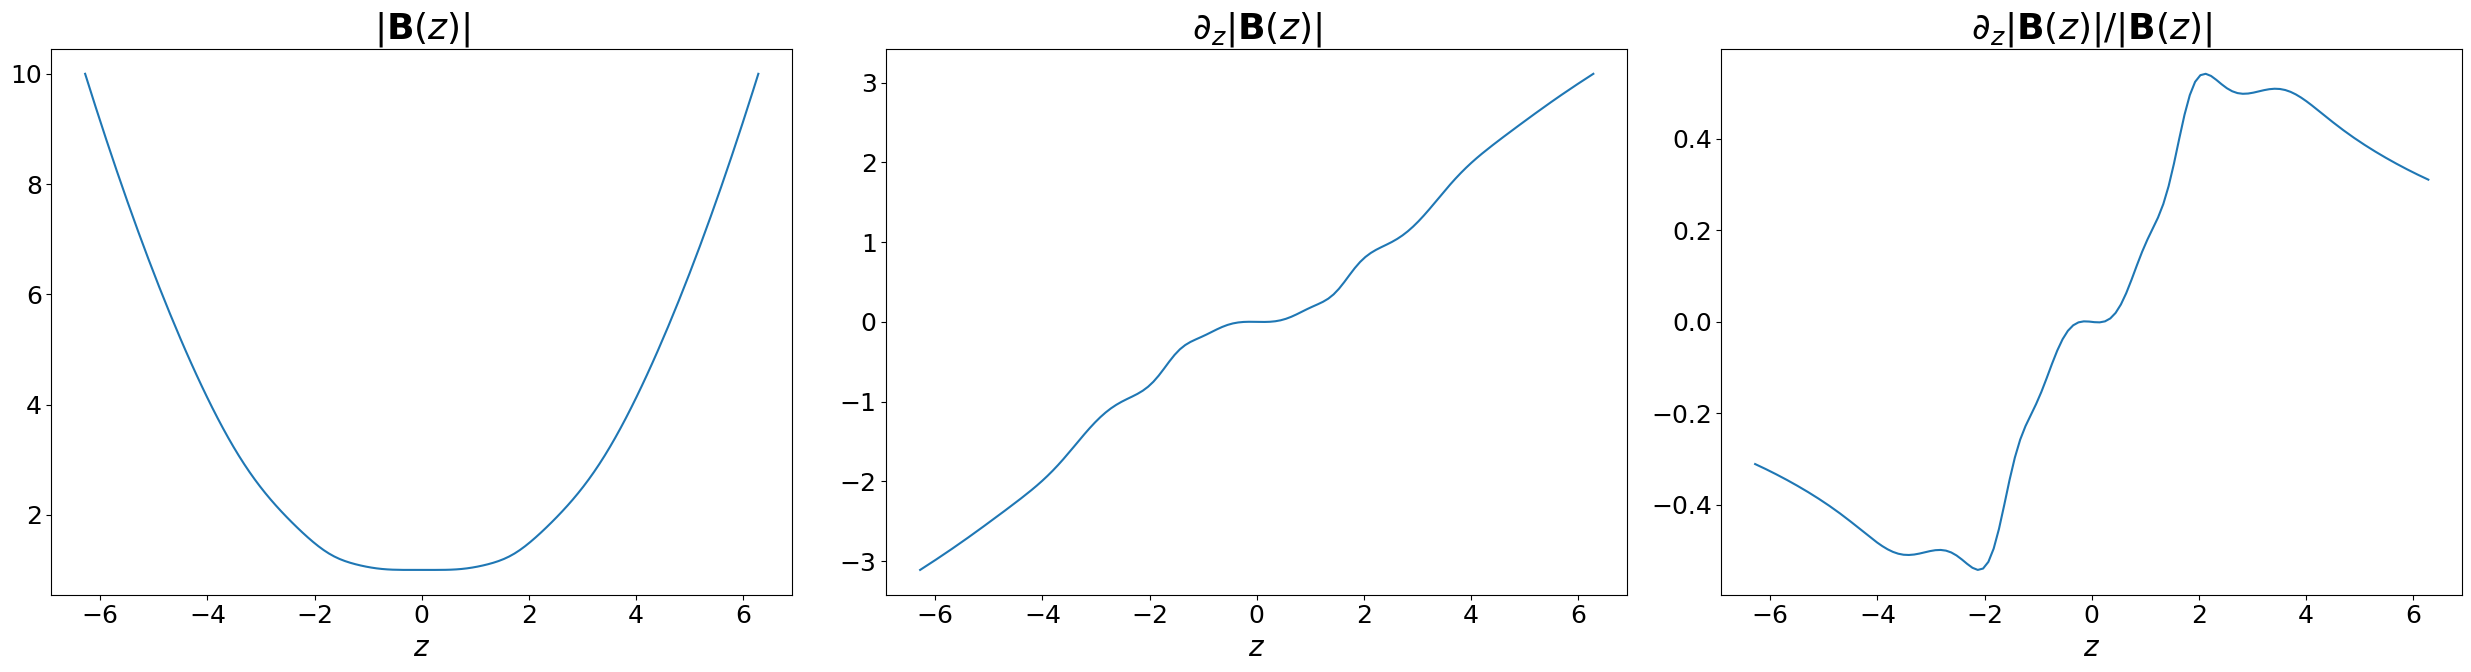

In [4]:
plot_magnetic_fields(B_eval, dB_eval, g_eval, zs)

#### Initial condition

In [5]:
sigma_z = 0.8

f_iv_e, f_iv_i = get_initial_distribution_multi(B_fn_grid, sigma_z,mesh, m_i)


print("\\int\\rho_i dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_i, x=mesh.mus, axis=2), x=mesh.vs_i, axis=1), x=mesh.zs, axis=0))
print("\\int\\rho_e dz: ", jnp.trapezoid(jnp.trapezoid(jnp.trapezoid(f_iv_e, x=mesh.mus, axis=2), x=mesh.vs_e, axis=1), x=mesh.zs, axis=0))

\int\rho_i dz:  1.0
\int\rho_e dz:  1.0


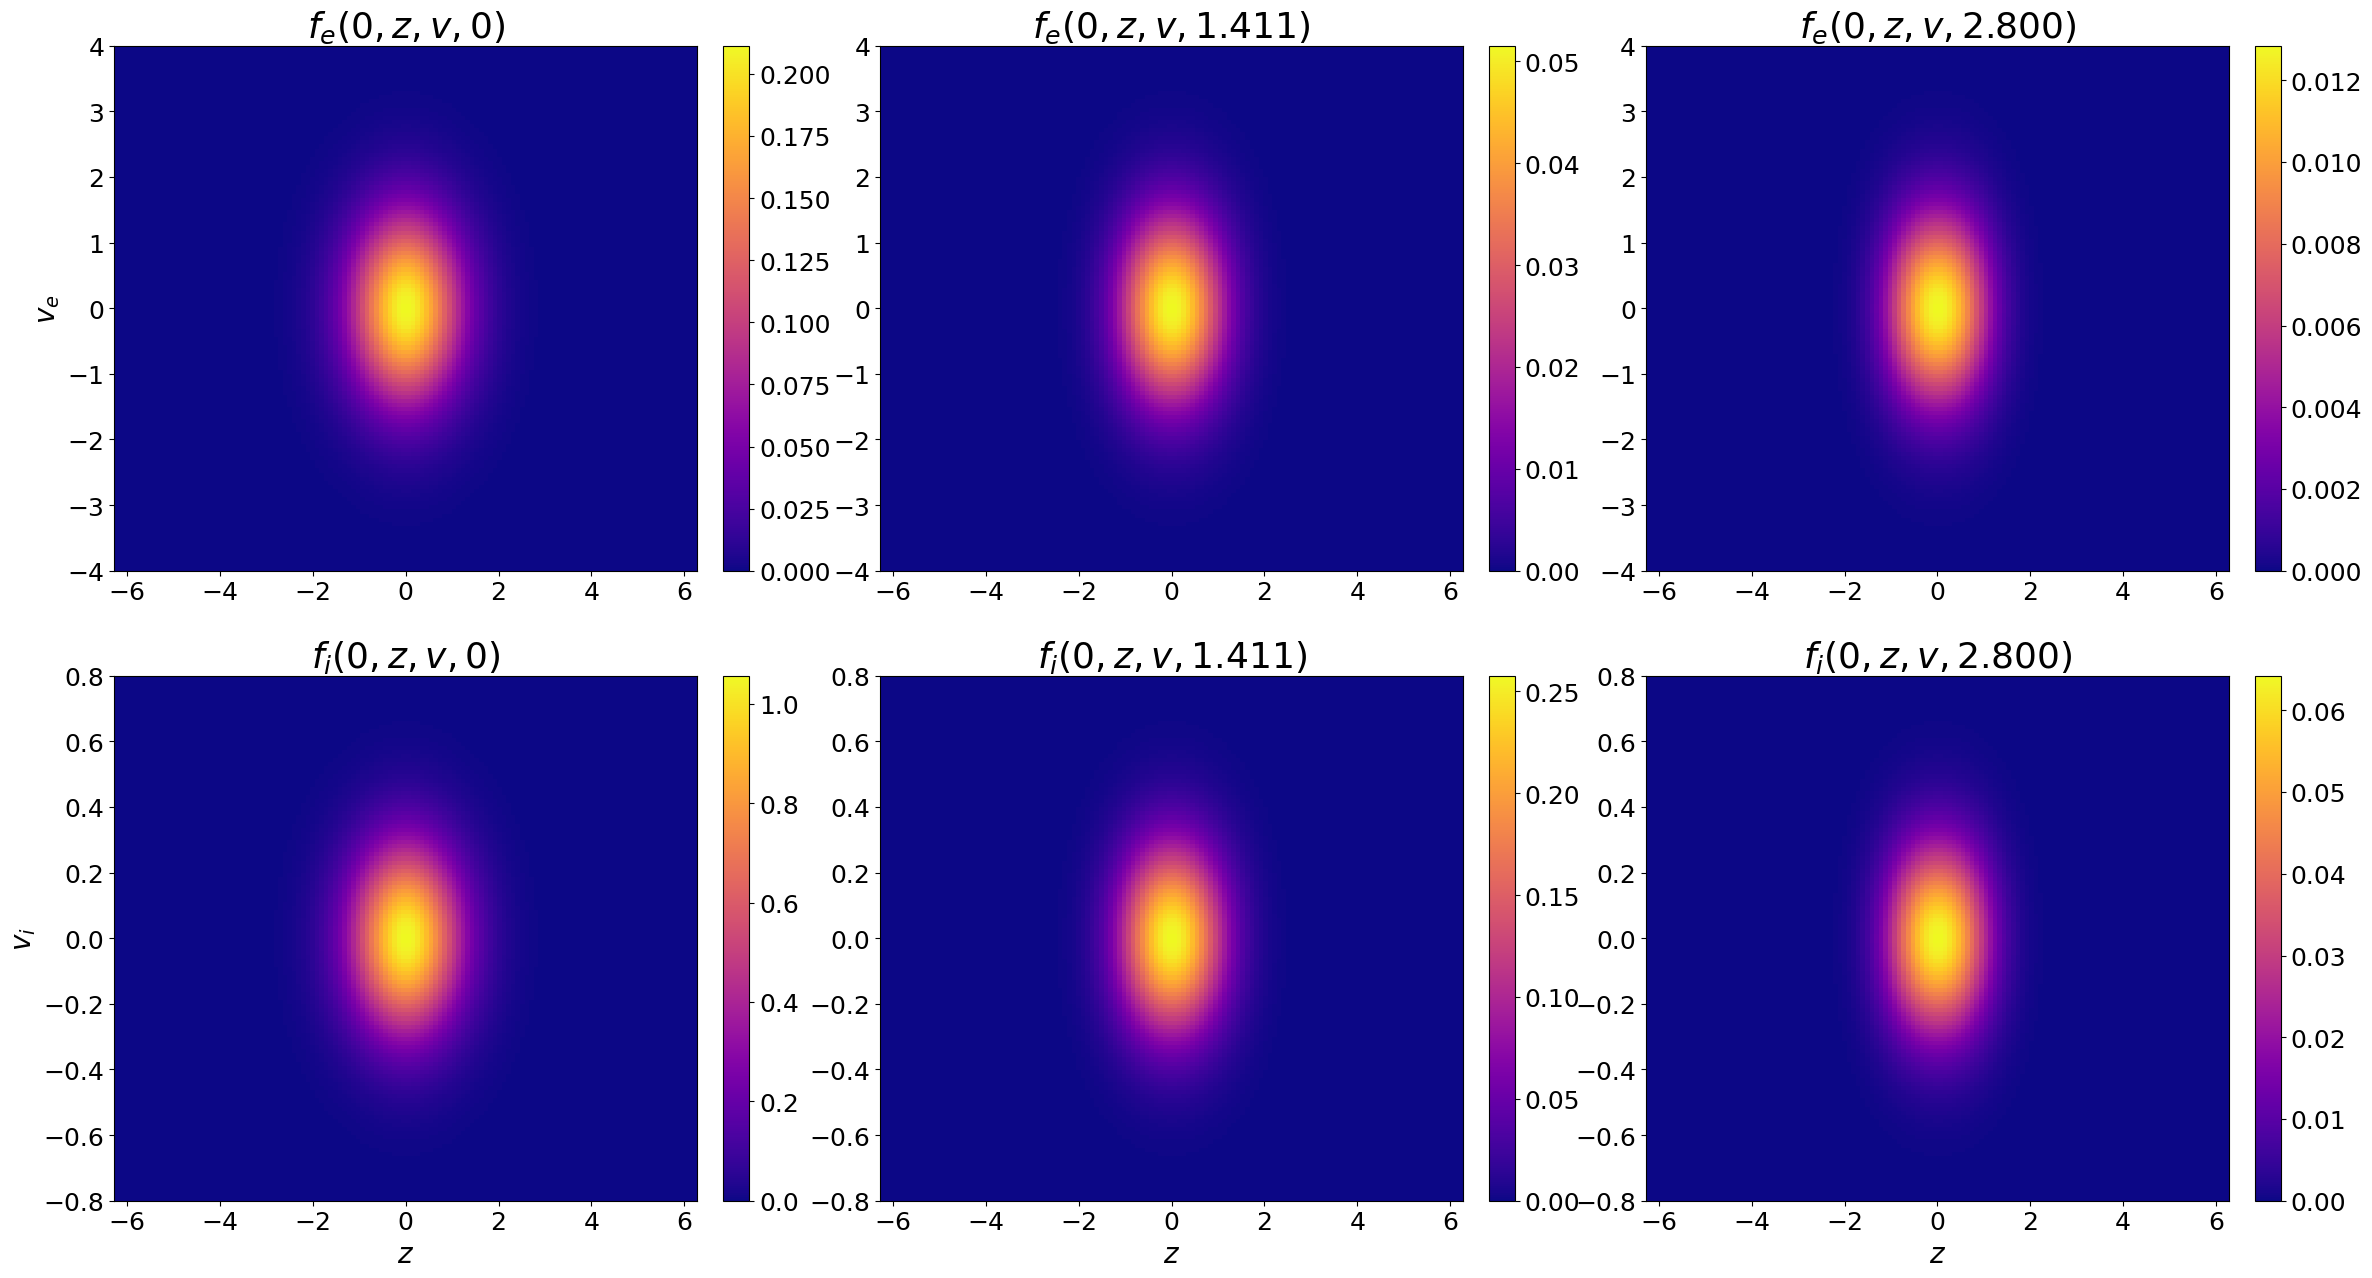

In [6]:
plot_initial_distribution_multi(f_iv_e, f_iv_i, mesh)

Since we are testing the effects of the electrical field we first simulate with $E(t,z)$ and then we simulate without $E(t,z)$ and see the differences.

In [7]:
solver = VlasovPoissonSolverFull(mesh=mesh, dt=dt, m_i=m_i)

# Initialize the combined Solver
solver_jit = eqx.filter_jit(solver.run_forward_jax_scan)
solver_jit_no_E = eqx.filter_jit(solver.run_forward_jax_scan_no_E)

### Numerical results

In [8]:
(f_e_array, f_i_array), E_total_array, ee_array, rho_e_array, rho_i_array = solver_jit(f_iv_e, f_iv_i, B_eval, dB_eval, g_eval, t_final)
(f_e_array_no_E, f_i_array_no_E), rho_e_array_no_E, rho_i_array_no_E = solver_jit_no_E(f_iv_e, f_iv_i, B_eval, dB_eval, g_eval, t_final)

In the figure below we plot the results without taking the electric field into acount and in the next figure we plot the restuls where we take the elctric field into account.

In [9]:
norm_il, norm_ic, norm_ir, norm_el, norm_ec, norm_er = normalize_final_E_effect_multi(f_e_array,
                                                                                      f_e_array_no_E, 
                                                                                      f_i_array, 
                                                                                      f_i_array_no_E, 
                                                                                      mesh)

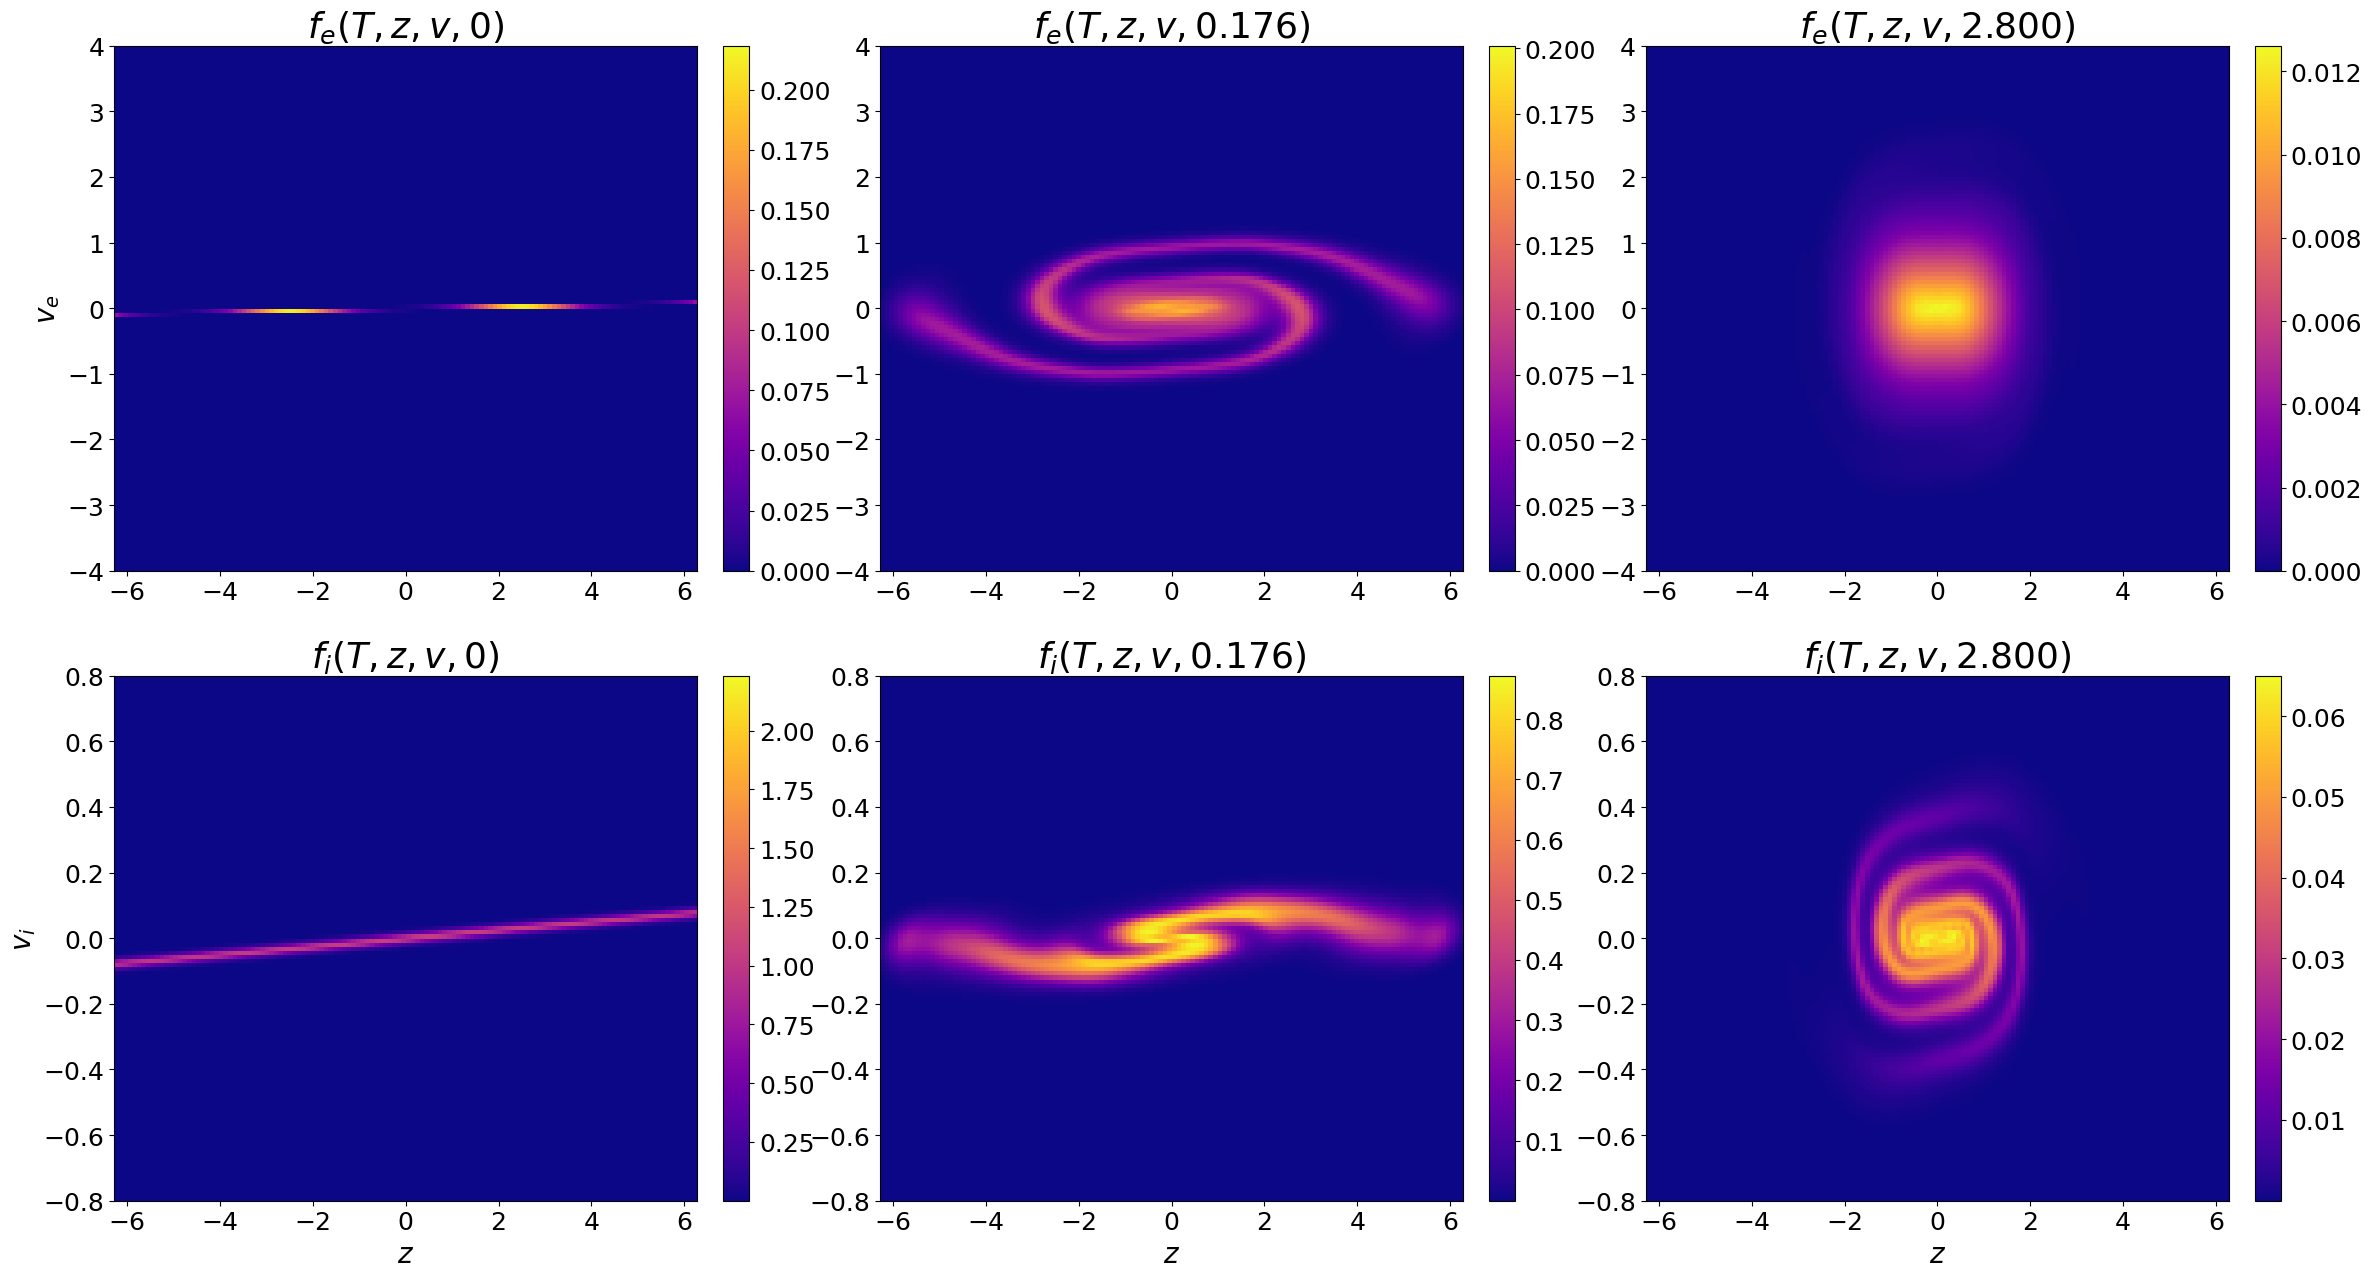

In [10]:
plot_final_distribution_multi(f_e_array_no_E, f_i_array_no_E,
                                   norm_il, norm_ic, norm_ir, norm_el, norm_ec, norm_er, mesh)

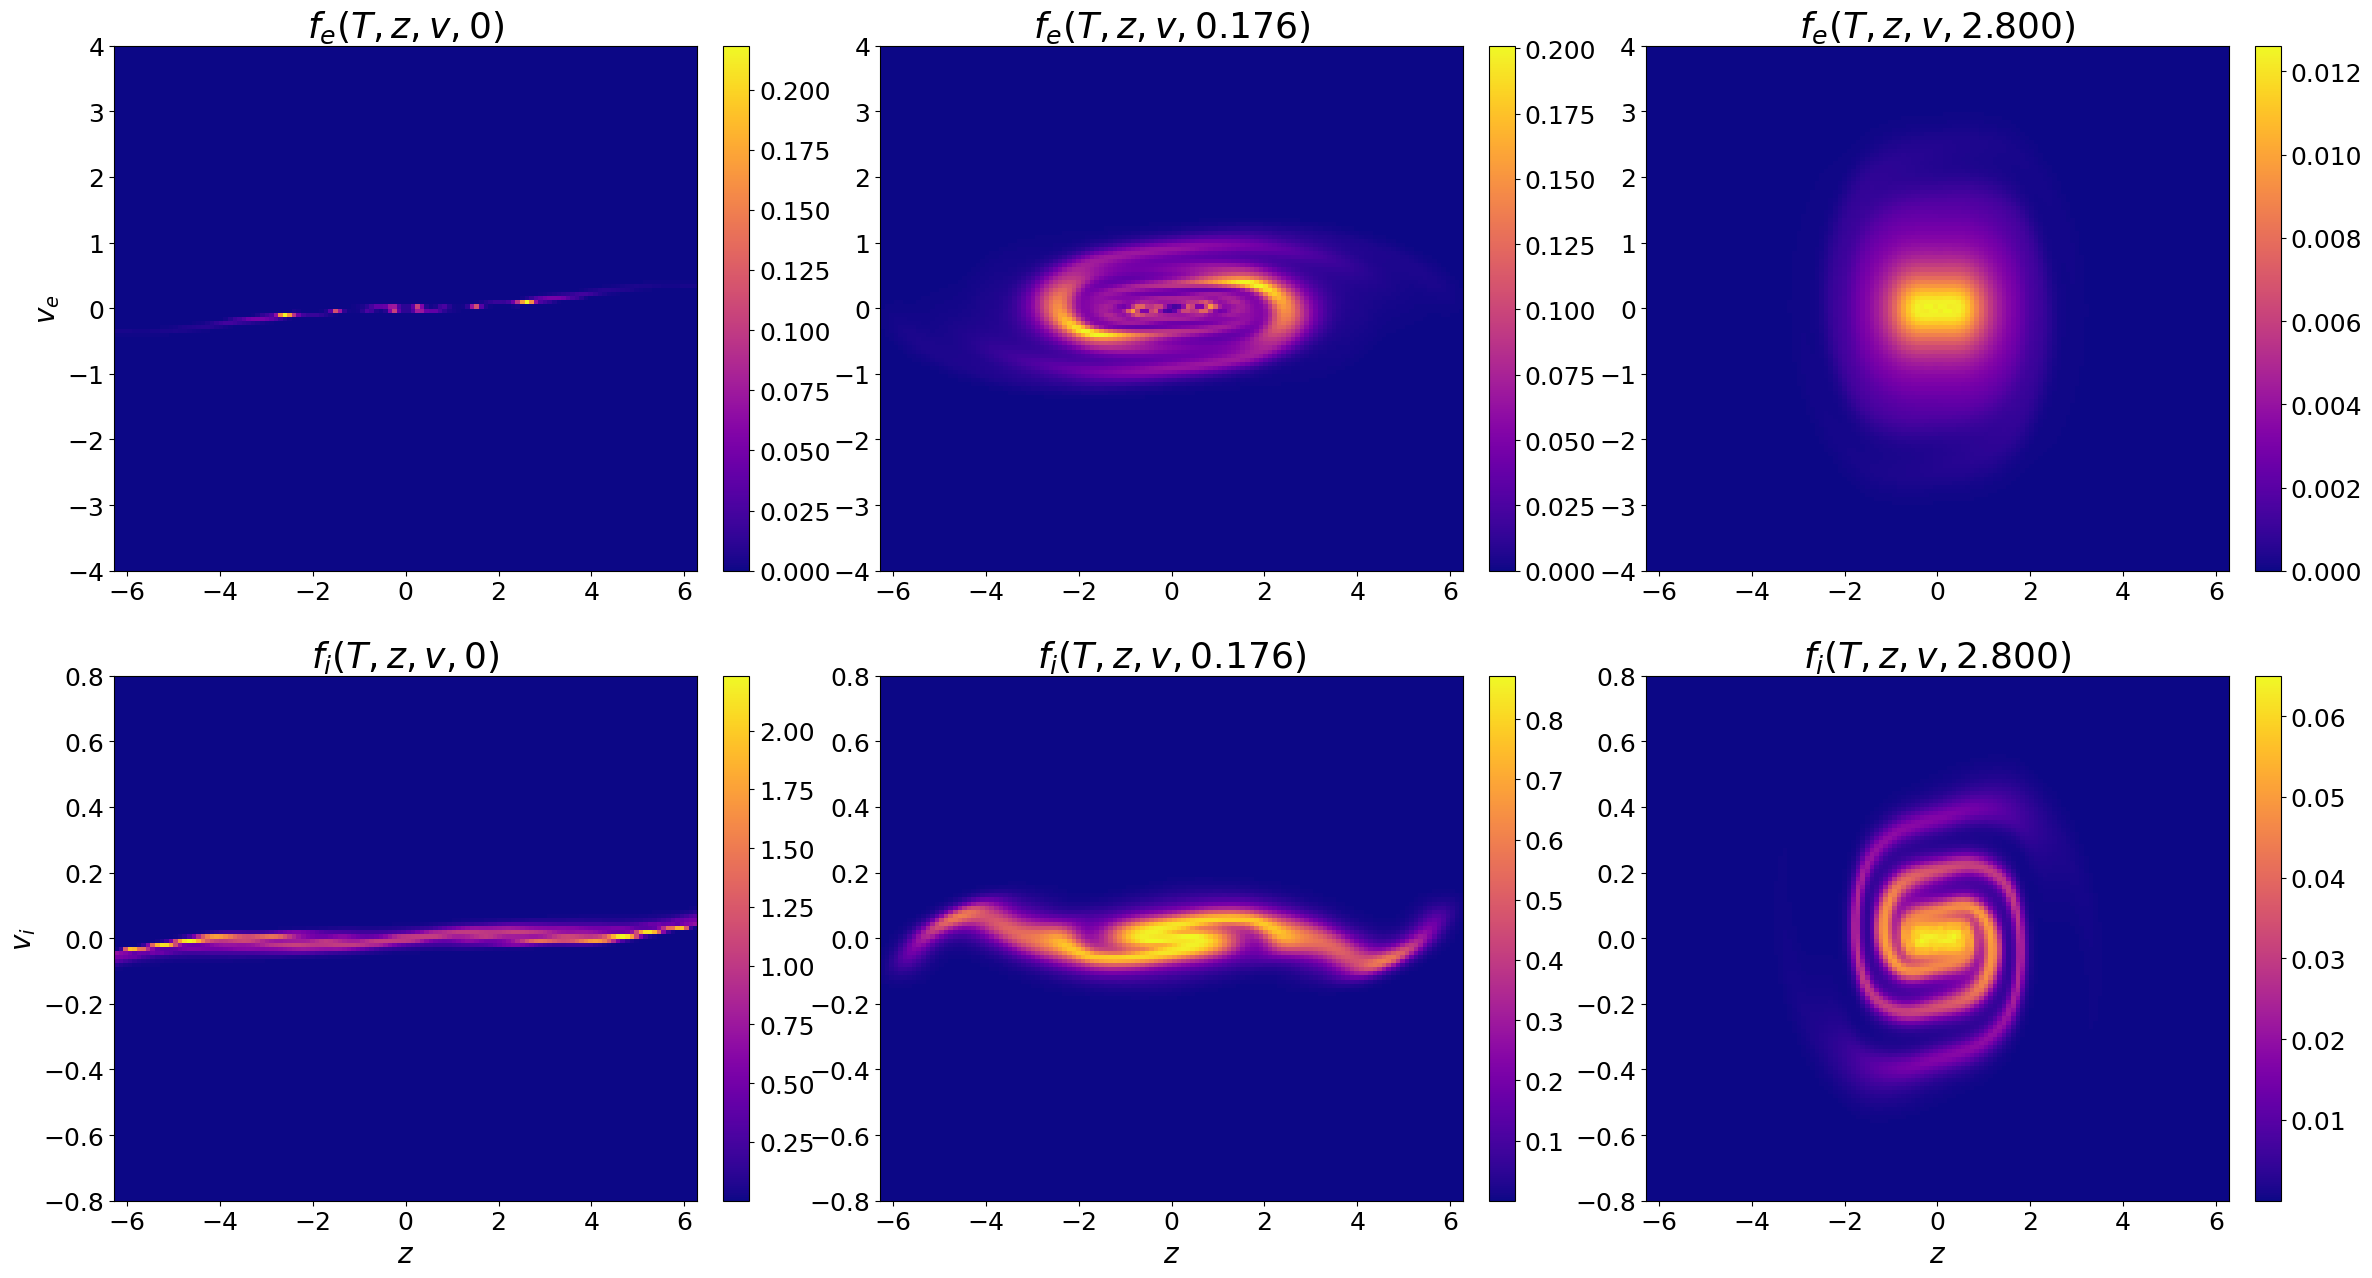

In [11]:
plot_final_distribution_multi(f_e_array, f_i_array,
                                   norm_il, norm_ic, norm_ir, norm_el, norm_ec, norm_er, mesh)

We plot the electrical energy $\mathcal{E}(t)$ defined as

$$
\mathcal{E}(t) = \frac{1}{2}\int_{-L_z}^{L_z}E(t,z)^{2}\,\mathrm{d}z\,. 
$$

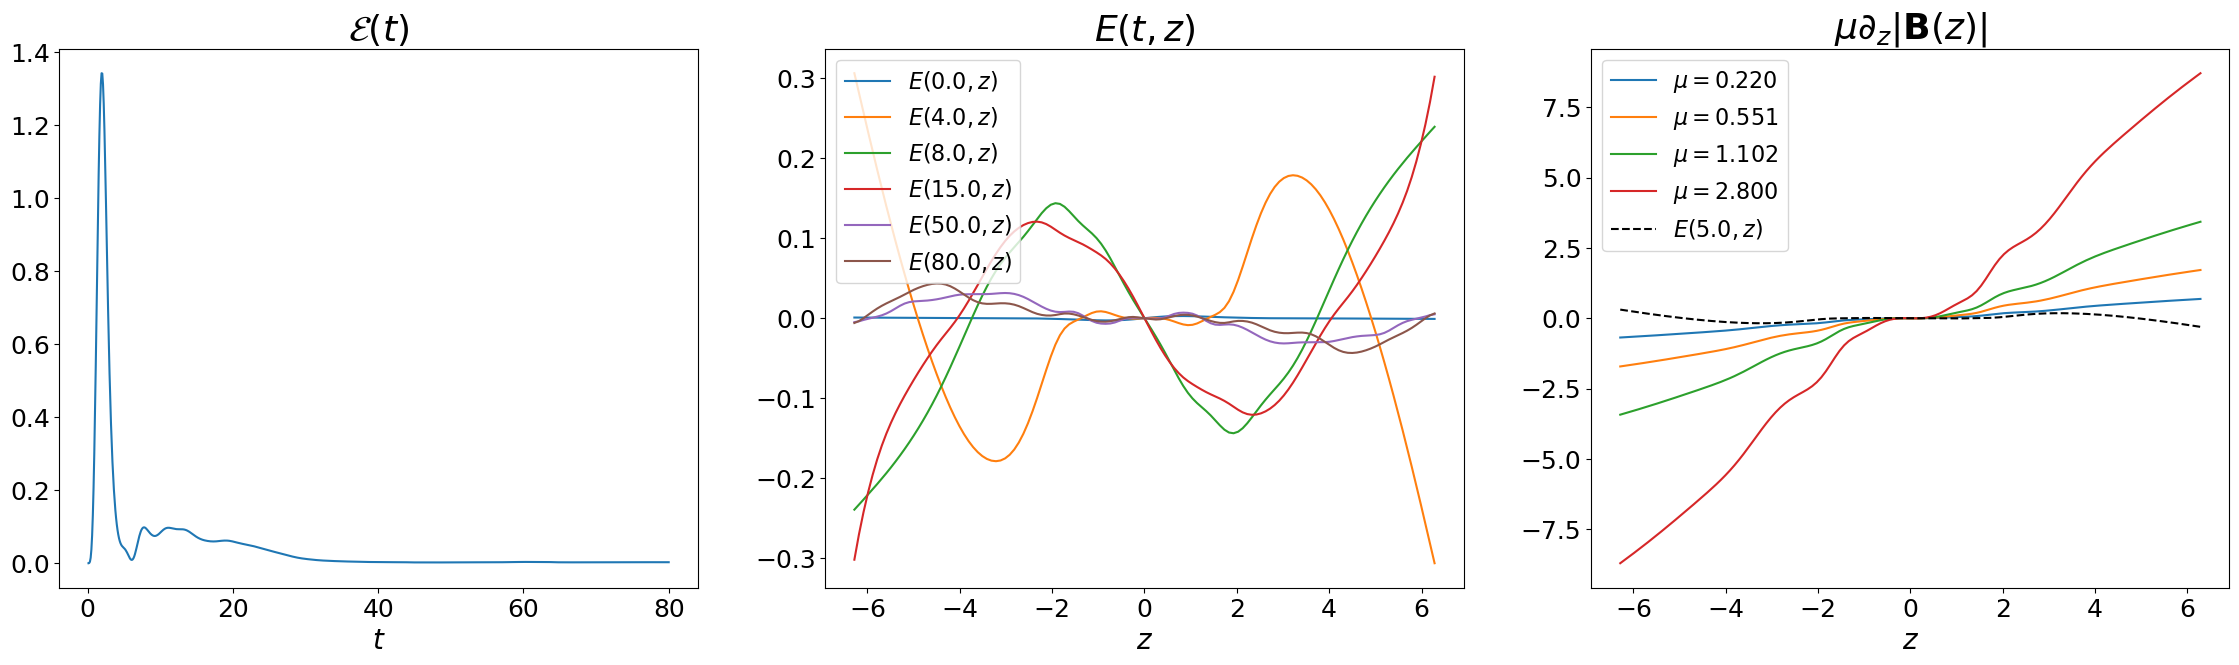

In [12]:
plot_energies_multi(t_values, ee_array, E_total_array, dB_eval, mesh)

We plot two density quantities $s\in \{e,i\}$: the three-dimensional density, which is given by

$$
\rho_s(t,z)
=
2\pi |\mathbf{B}(z)|
\iint
f_s(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,,
$$
and the effective longitudinal density, which is given by
$$
\rho_s^{1D}(t,z)
=
\iint
f_s(t,z,v,\mu)
\,\mathrm{d}v\,\mathrm{d}\mu\,.
$$

In addition, to see the level of confinement in time we plot

$$\int_{-L_z}^{L_z}\rho_s^{1D}(t,z)\,\mathrm{d}z\,.$$

Here, the effect of $E$ on confinement becomes much clearer.

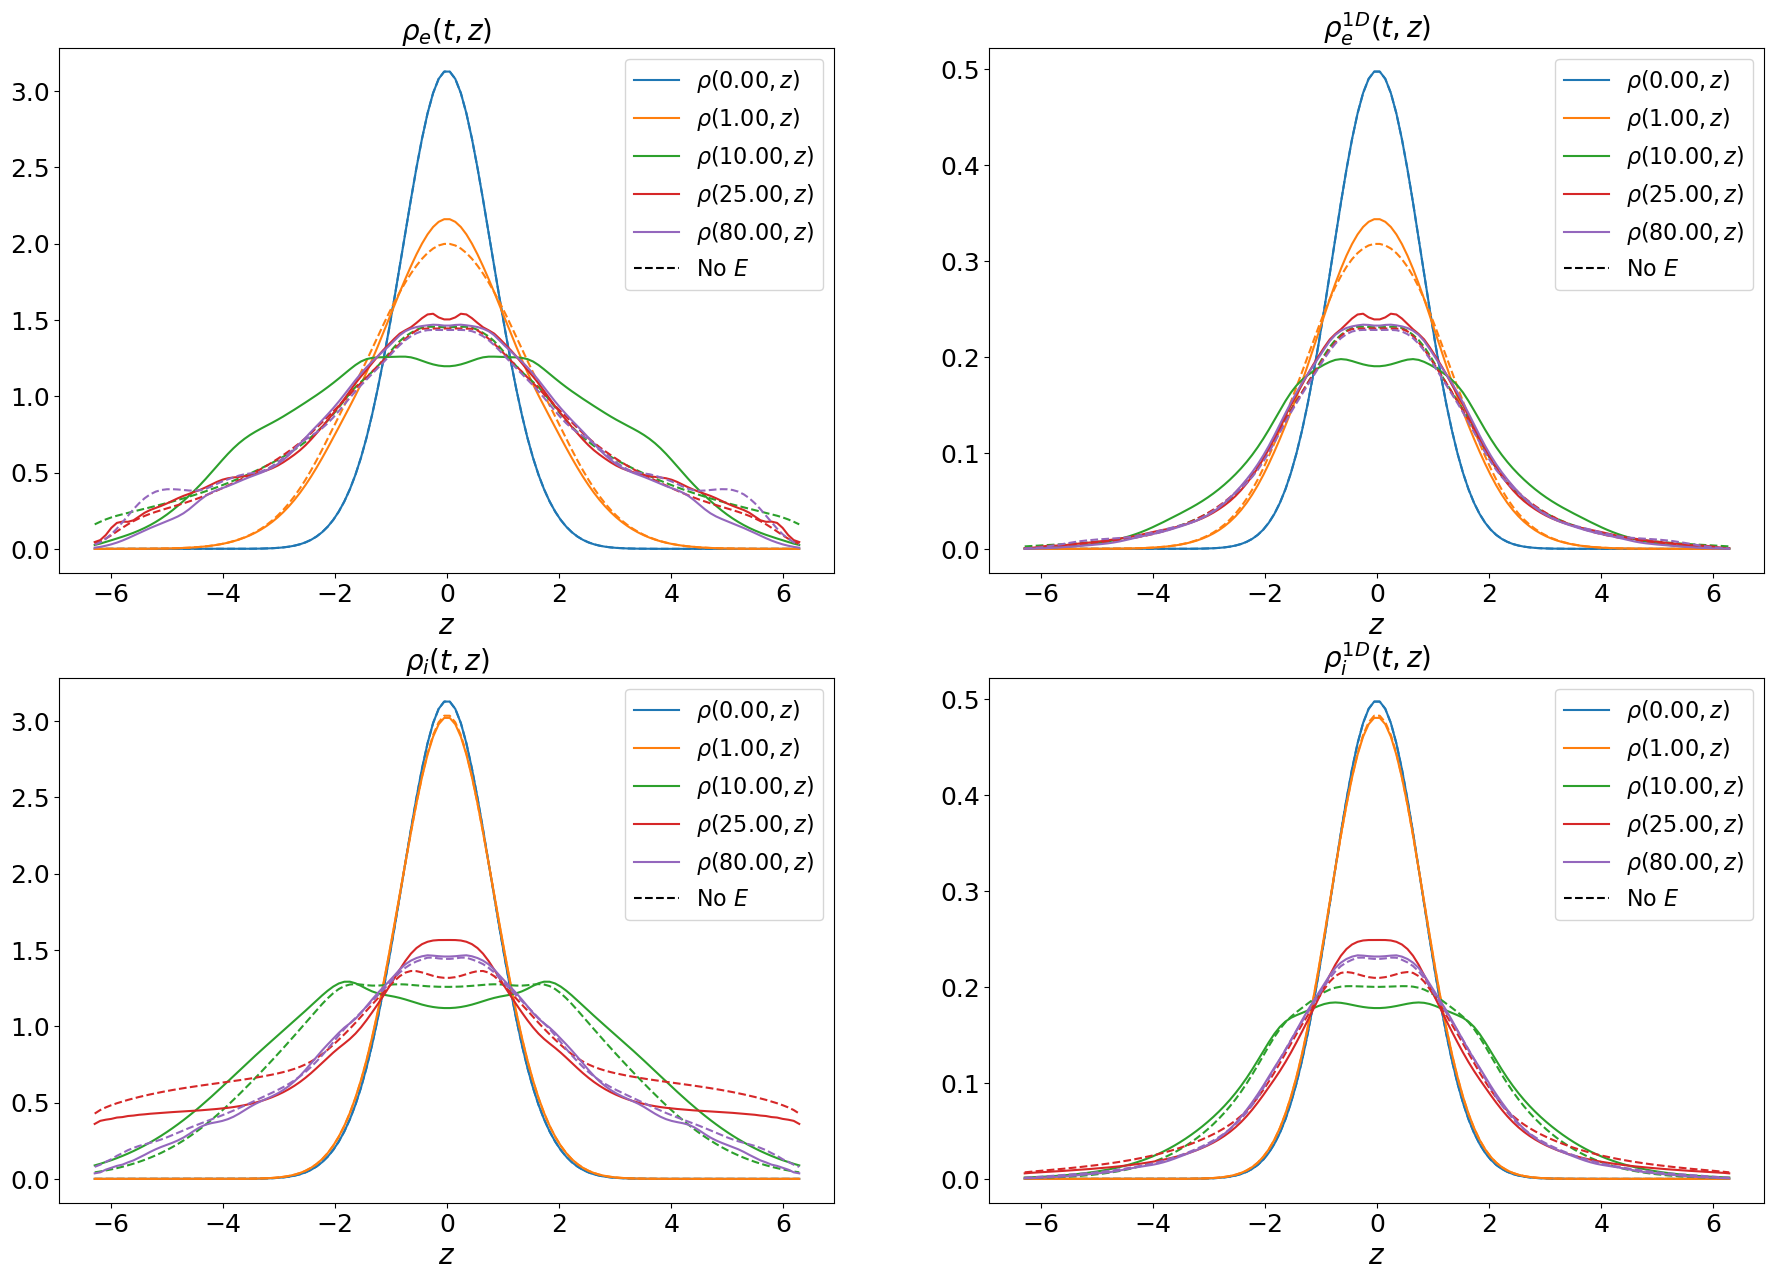

In [13]:
plot_rhos_multi(rho_e_array, rho_e_array_no_E, rho_i_array, rho_i_array_no_E, B_eval, t_values, mesh)

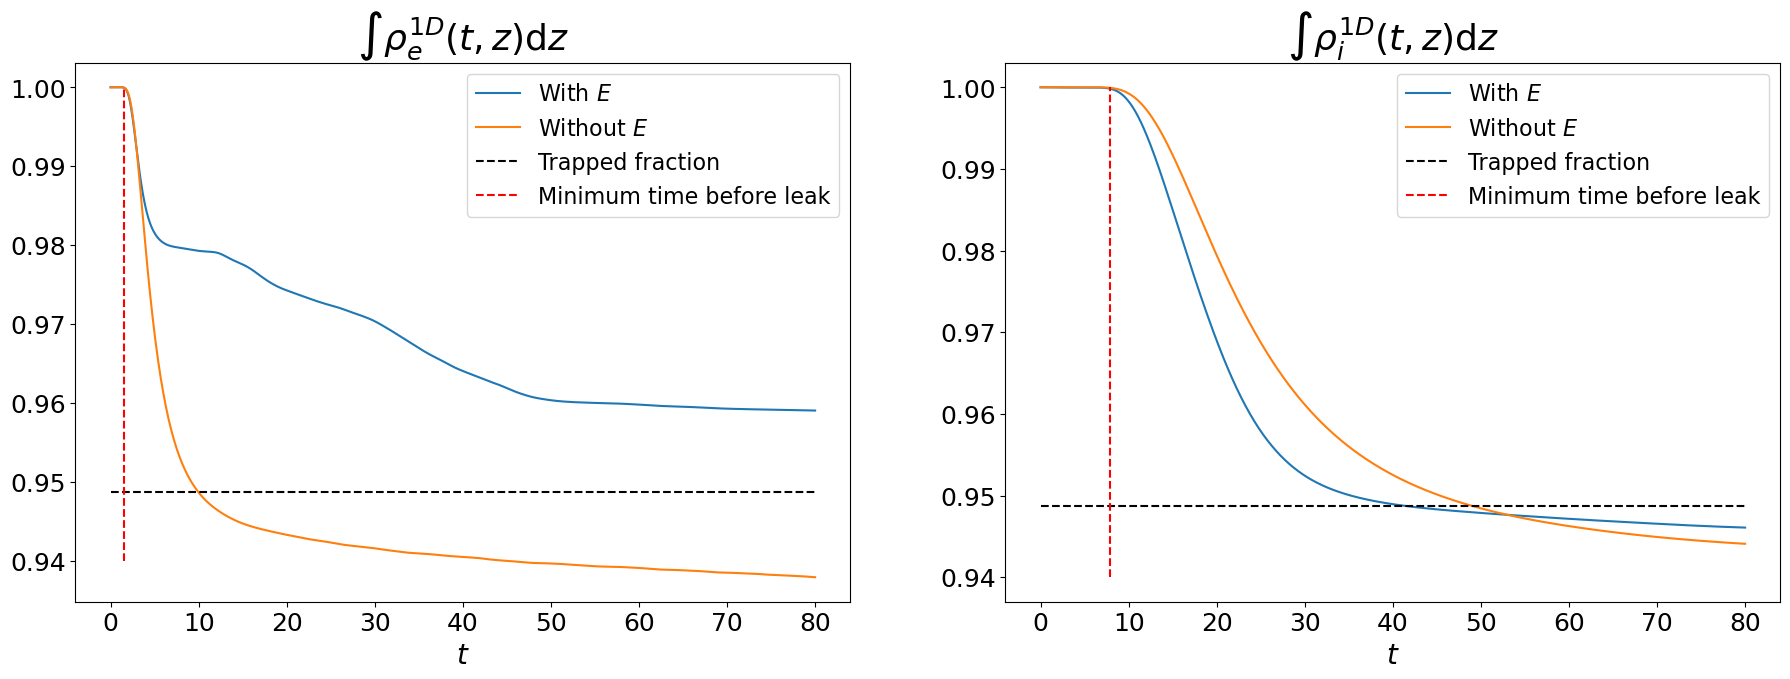

In [14]:
plot_int_rho_multi(rho_e_array, rho_e_array_no_E, rho_i_array, rho_i_array_no_E, prop_trapped, LZ, LV, m_i, t_values, mesh)